# Question 1

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Generate Data

In [2]:
product_ids = np.random.randint(1001,1010,size=100)
quantities = np.random.randint(1,5,size=100)
prices = np.random.uniform(10,100,size=100).round(2)
random_dates = pd.to_datetime(np.random.choice(pd.date_range("2025-01-01","2025-01-10"),size=100))
sales_df = pd.DataFrame({"ProductID":product_ids,"Quantity":quantities,"Price":prices,"Date":random_dates})
sales_df

,ProductID,Quantity,Price,Date
0,1002,4,47.06,2025-01-03
1,1007,4,16.21,2025-01-02
2,1004,3,47.09,2025-01-09
3,1005,1,40.34,2025-01-01
4,1001,4,21.23,2025-01-03
...,...,...,...,...
95,1003,4,56.88,2025-01-05
96,1006,1,98.76,2025-01-04
97,1003,1,46.72,2025-01-03
98,1003,4,62.82,2025-01-09


### Adding TotalSales Column

In [3]:
sales_df["TotalSale"] = sales_df["Quantity"] * sales_df["Price"]
sales_df

,ProductID,Quantity,Price,Date,TotalSale
0,1002,4,47.06,2025-01-03,188.24
1,1007,4,16.21,2025-01-02,64.84
2,1004,3,47.09,2025-01-09,141.27
3,1005,1,40.34,2025-01-01,40.34
4,1001,4,21.23,2025-01-03,84.92
...,...,...,...,...,...
95,1003,4,56.88,2025-01-05,227.52
96,1006,1,98.76,2025-01-04,98.76
97,1003,1,46.72,2025-01-03,46.72
98,1003,4,62.82,2025-01-09,251.28


###  Introduce Missing Data

In [17]:
np.random.seed(42)
nan_indices = np.random.choice(sales_df.index,size=5,replace=False)
sales_df.loc[nan_indices,"Price"] = np.nan
print(sales_df["Price"].isna().sum())
mean_price = sales_df["Price"].mean()
sales_df.Price = sales_df["Price"].fillna(mean_price)
print(sales_df)

5
    ProductID  Quantity  Price       Date  TotalSale
0        1002         4  47.06 2025-01-03     188.24
1        1007         4  16.21 2025-01-02      64.84
2        1004         3  47.09 2025-01-09     141.27
3        1005         1  40.34 2025-01-01      40.34
4        1001         4  21.23 2025-01-03      84.92
..        ...       ...    ...        ...        ...
95       1003         4  56.88 2025-01-05     227.52
96       1006         1  98.76 2025-01-04      98.76
97       1003         1  46.72 2025-01-03      46.72
98       1003         4  62.82 2025-01-09     251.28
99       1004         4  27.92 2025-01-01     111.68

[100 rows x 5 columns]


### Group and Aggregate

In [41]:
#Total quantity sold
total_quantity_sold = sales_df.groupby("ProductID").Quantity.sum() 
print(total_quantity_sold)
#Total revenue
total_revenue = sales_df.groupby("ProductID").TotalSale.sum()
print(total_revenue)

ProductID
1001    32
1002    15
1003    29
1004    25
1005    24
1006    36
1007    37
1008    28
1009    16
Name: Quantity, dtype: int32
ProductID
1001    1709.73
1002     925.71
1003    1505.99
1004    1123.33
1005    1085.39
1006    1802.84
1007    1874.31
1008    1469.72
1009     980.90
Name: TotalSale, dtype: float64


### Visualizing Data

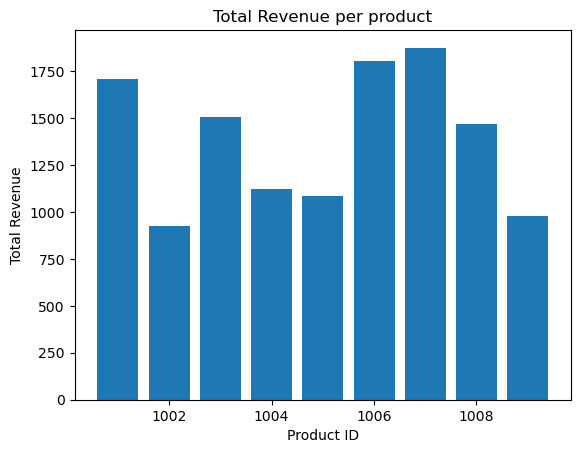

In [60]:
#Bar Chart
plt.bar(total_revenue.index,total_revenue.values)
plt.xlabel("Product ID")
plt.ylabel("Total Revenue")
plt.title("Total Revenue per product")
plt.show()

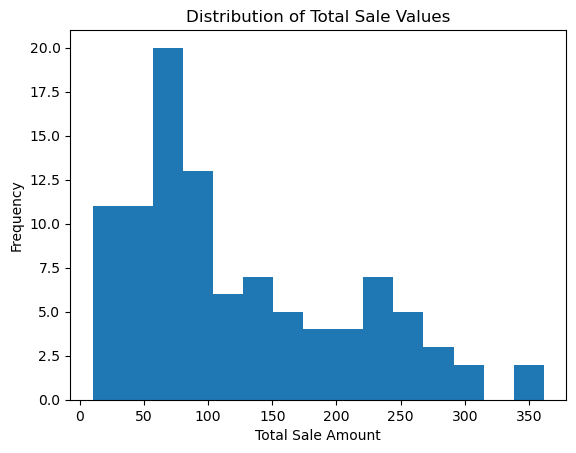

In [63]:
plt.hist(sales_df["TotalSale"],bins=15)
plt.xlabel("Total Sale Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Total Sale Values")
plt.show()

Text(0.5, 1.0, 'Revenue per product')

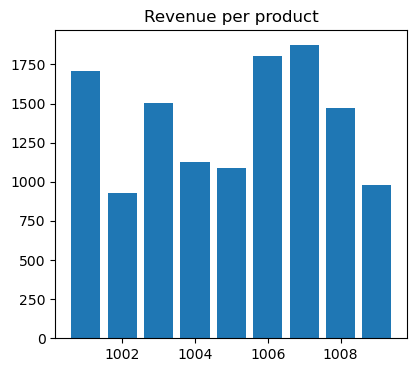

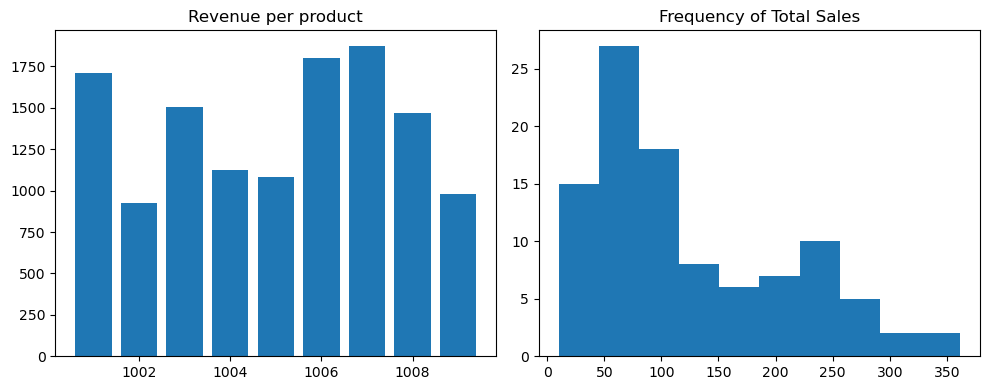

In [76]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(total_revenue.index,total_revenue.values)
plt.title("Revenue per product")
plt.subplot(1,2,2)
plt.hist(sales_df["TotalSale"],bins=10)
plt.title("Frequency of Total Sales")
plt.tight_layout()
plt.show()